<a href="https://colab.research.google.com/github/reedx8/xception-dogvcat/blob/main/Xception_Dog_v_Cats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Xception pretrained model on small dog v cat dataset from Kaggle competition @ https://www.kaggle.com/competitions/dogs-vs-cats/data. Balanced binary classification problem. DLWP, 2026

# Login to kaggle IOT download Kaggle Dogs vs Cats dataset
import os
from google.colab import userdata
import zipfile

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

# Downloading dogs vs cats dataset from kaggle:
!kaggle competitions download -c dogs-vs-cats

# Unzip dataset(dogs-vs-cats.zip) and then only unzip training images (train.zip -> /train folder)
with zipfile.ZipFile('dogs-vs-cats.zip', 'r') as zip_ref:
    zip_ref.extractall(".")

with zipfile.ZipFile('train.zip', 'r') as zip_ref:
    zip_ref.extractall(".")



100% 812M/812M [00:09<00:00, 87.2MB/s]



In [7]:
# Copying images to training, validation, and test directories
import os, shutil, pathlib
original_dir = pathlib.Path("train")
new_base_dir = pathlib.Path("dogs_vs_cats_small")

def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir)
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname, dst=dir / fname)

make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

# directory should now look like the following:
# dogs_vs_cats_small/
# ...train/
# ......cat/   <- contains 1000 cat images
# ......dog/   <- contains 1000 dog images
# ...validation/
# ......cat/   <- contains 500 cat images
# ......dog/   <- contains 500 dog images
# ...test/
# ......cat/   <- 1000 cat iamges
# ......dog/   <- 1000 dog images



In [9]:
# Preprocess data
from keras.utils import image_dataset_from_directory as img_data

# new_base_dir = dogs_vs_cats_small/

batch_size = 64
image_size = (180,180) # image size you want
train_dataset = img_data(new_base_dir / "train", image_size=image_size, batch_size=batch_size)
validation_dataset = img_data(new_base_dir / "validation", image_size=image_size, batch_size=batch_size)
test_dataset = img_data(new_base_dir / "test", image_size=image_size, batch_size=batch_size)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [10]:
# Xception pretrained model
import keras_hub # For importing pretrained models
# import keras

# backbone = underlying feature extractor w/ot classification head
conv_base = keras_hub.models.Backbone.from_preset("xception_41_imagenet")

# Rescale images to match pretained model -- avoids relearning how to extract images with a diff input range
preprocessor = keras_hub.layers.ImageConverter.from_preset(
    "xception_41_imagenet",
    image_size=(180, 180),
)

In [16]:
# Extracting the image features and corresponding labels -- technique 1: using fast feature extraction (extracting Xception's features into numpy arrays) without data augmentation (faster, but cant use data augmention). predict() expects images not labels but our dataset has bot
import numpy as np
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = preprocessor(images)
        features = conv_base.predict(preprocessed_images, verbose=0)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

# extracted features are now of shape (samples, 6, 6, 2048)
# train_features.shape


In [17]:
# Defining and training the densely connected classifier -- 2 dense layers only
import keras
from keras import layers

# Defining model
inputs = keras.Input(shape=(6,6,2048)) # fit the model to data
x = layers.GlobalAveragePooling2D()(inputs)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)


# Save best model (feature_extraction.keras) from best performing epoch
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

# Train model
history = model.fit(
    train_features,
    train_labels,
    epochs=10,
    validation_data=(val_features, val_labels),
    callbacks=callbacks,
)



Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9625 - loss: 0.1124 - val_accuracy: 0.9840 - val_loss: 0.0427
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9925 - loss: 0.0210 - val_accuracy: 0.9830 - val_loss: 0.0633
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9945 - loss: 0.0159 - val_accuracy: 0.9820 - val_loss: 0.0508
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9935 - loss: 0.0143 - val_accuracy: 0.9890 - val_loss: 0.0464
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9985 - loss: 0.0050 - val_accuracy: 0.9880 - val_loss: 0.0520
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9880 - val_loss: 0.0550
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9840 - val_loss: 0.0605
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 1.0000 - loss: 7.9100e-04 - val_accuracy: 0.9880

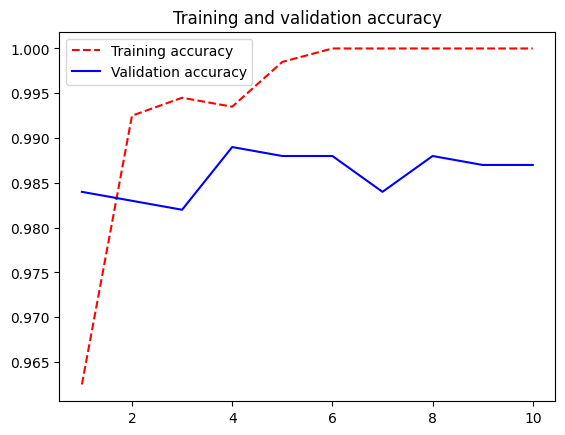

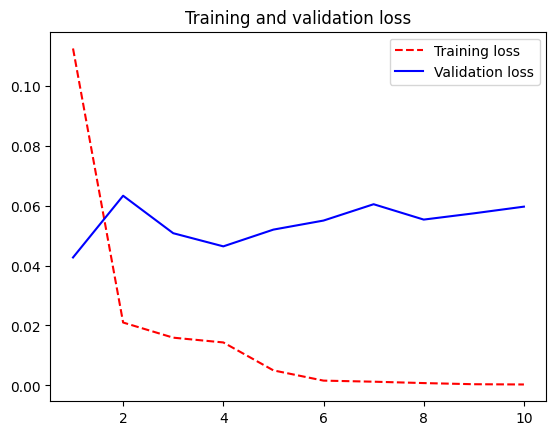

In [18]:
# Plotting the loss and accuracy of the model over the training and validation data during training -- reach validation accuracy of over 98%, far better (18% accuracy improvement) than custom convnet ("CNN Dog v Cat" notebook).
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [19]:
# Pretrained model reached 98.4% test accuracy on unseen data
test_model = keras.models.load_model("feature_extraction.keras")
test_loss, test_acc = test_model.evaluate(test_features, test_labels)
print(f'Test accuracy: ${test_acc:.3f} ')

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9835 - loss: 0.0555
Test accuracy: $0.984 


In [ ]:
#Technique 2: feature extraction with data augmentation -- adds a new dense classifier and training it end to end on the inputs. Must freeze the conv base (prevents weights from being updated during training, set trainable attrib to false), without which previous conv base will be overwritten
conv_base = keras_hub.models.Backbone.from_preset(
    "xception_41_imagenet",
    trainable=False,
)

# Can run the following to check if its frozen (returns 0)
# print(len(conv_base.trainable_weights))


In [20]:
# Defining a data augmentation stage to mitigate overfitting identified in valid vs training chart
import tensorflow as tf
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
]

def data_augmentation(images, targets):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images, targets

augmented_train_dataset = train_dataset.map(
    data_augmentation, num_parallel_calls=8
)
augmented_train_dataset = augmented_train_dataset.prefetch(tf.data.AUTOTUNE)

In [ ]:
# TODO -- A new model that chains together our frozen conv base and the new dense classifier (only 2 dense layers) while using data augmentation
inputs = keras.Input(shape=(180, 180, 3))
x = preprocessor(inputs)
x = conv_base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

# save best model
callbacks=[
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_with_data_augmentation.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

history = model.fit(
    augmented_train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks,
)
